# 02 · Guesstimates for Data Science Problems

Same six-step method as notebook 01 (clarify, structure, assume, calculate, sanity-check, sensitivity), now on problems that come up in real data and product work. They get harder as we go.

| # | Problem | Level |
|---|---|---|
| 4 | Smartphones sold in India per year | medium |
| 5 | Daily active users of a food delivery app in one city | medium |
| 6 | Google searches per second | medium |
| 7 | Storage needed for photos on a social app, per year | hard |
| 8 | Monthly revenue of a freemium subscription app | hard |
| 9 | How long must an A/B test run? | hard |

When I compare my estimate with a published figure, the figure is only a sanity check, quoted approximately. The point is the reasoning, not hitting an exact number.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

BLUE = "#2a78d6"
ORANGE = "#eb6834"

The two helpers from notebook 01, copied here so this notebook runs on its own.

In [2]:
def sensitivity(estimate_function, assumptions, ranges):
    # change one assumption at a time, keep the others at their base value
    base_result = estimate_function(**assumptions)
    rows = []
    for name, (low, high) in ranges.items():
        result_low = estimate_function(**{**assumptions, name: low})
        result_high = estimate_function(**{**assumptions, name: high})
        rows.append({"assumption": name, "low value": low, "high value": high,
                     "result if low": result_low, "result if high": result_high})
    table = pd.DataFrame(rows)
    table["swing"] = (table["result if high"] - table["result if low"]).abs()
    return base_result, table.sort_values("swing")


def tornado_chart(base_result, table, title, unit, scale=1):
    base = base_result / scale
    fig, ax = plt.subplots(figsize=(8, 0.6 * len(table) + 1.5))
    for i, (_, row) in enumerate(table.iterrows()):
        smallest = min(row["result if low"], row["result if high"]) / scale
        largest = max(row["result if low"], row["result if high"]) / scale
        ax.barh(i, base - smallest, left=smallest, color=ORANGE, height=0.5)
        ax.barh(i, largest - base, left=base, color=BLUE, height=0.5)
    ax.axvline(base, color="black", linewidth=1, label="base estimate")
    ax.set_yticks(range(len(table)))
    ax.set_yticklabels(table["assumption"])
    ax.set_title(title)
    ax.set_xlabel(unit)
    ax.margins(x=0.08)
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

---
## Problem 4 (medium): How many smartphones are sold in India per year?

### 1. Clarify

- New smartphones sold (shipped) in one year, all brands, all prices.
- Second-hand phones don't count.

### 2. Structure

People buy a phone for two reasons: they replace an old one, or they are buying their first one.

```
phones sold per year = replacement purchases + first-time purchases
replacement purchases = smartphone users / years between purchases
first-time purchases  = new smartphone users per year
smartphone users      = population × share aged 12+ × share of them with a smartphone
```

### 3. Assumptions

| Assumption | Value | Reason |
|---|---|---|
| Population | 1.43 billion | India's population, roughly |
| Share aged 12+ | 80% | Young children don't have their own phone |
| Smartphone share among 12+ | 60% | Very common in cities, less in villages. Many people still use basic phones |
| Years between purchases | 2.5 | A typical phone lasts 2-3 years before it gets slow or breaks |
| New smartphone users per year | 30 million | Adoption is still growing, but slowing down |

In [3]:
def india_smartphones(population, share_12_plus, smartphone_share, replacement_years, new_users):
    users = population * share_12_plus * smartphone_share
    return users / replacement_years + new_users

base = {"population": 1.43e9, "share_12_plus": 0.80, "smartphone_share": 0.60,
        "replacement_years": 2.5, "new_users": 30e6}

users = 1.43e9 * 0.80 * 0.60
first_try = india_smartphones(**base)
print(f"Smartphone users: {users / 1e6:,.0f} million")
print(f"First estimate  : {first_try / 1e6:,.0f} million phones per year")

Smartphone users: 686 million
First estimate  : 305 million phones per year


By hand: users = 1,430M × 0.8 × 0.6 ≈ 686M. Replacements = 686M / 2.5 ≈ 275M. Plus 30M new → **about 300 million** phones a year.

### 5. Sanity check, and a correction

Industry trackers have reported roughly **145-150 million** smartphones shipped in India per year recently. My first estimate is **twice** that. Same order of magnitude, but a 2× gap is worth investigating. Which assumption is most likely wrong?

- **Users (686 million):** published estimates of smartphone users in India are in the same range, so this is probably fine.
- **Replacement every 2.5 years:** this is the weak point. In India, a phone is often passed on to a family member or sold second-hand, and budget phones are used until they really stop working. So the **average** time between new-phone purchases per user is longer. Something like **4-5 years** is more realistic.

In [4]:
corrected = {**base, "replacement_years": 4.5}
second_try = india_smartphones(**corrected)
print(f"With 4.5 years between new purchases: {second_try / 1e6:,.0f} million phones per year")

With 4.5 years between new purchases: 183 million phones per year


With 4.5 years the estimate is **about 180 million**, much closer to the reported figure. Correcting a wrong turn openly like this is a normal part of a guesstimate. The goal is clear reasoning, not a lucky first number.

### 6. Sensitivity

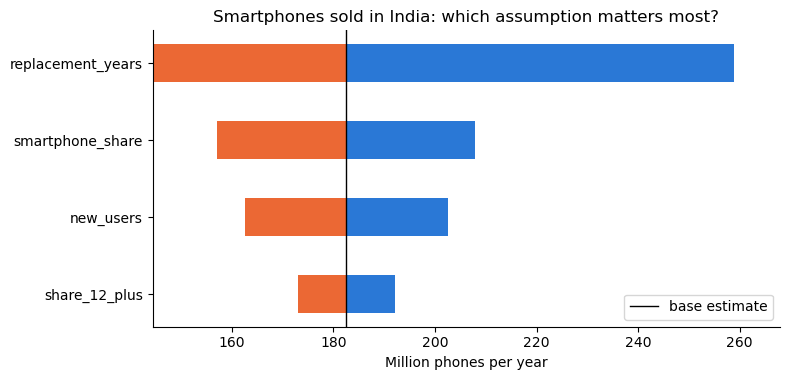

In [5]:
ranges = {
    "smartphone_share": (0.50, 0.70),
    "replacement_years": (3.0, 6.0),
    "new_users": (10e6, 50e6),
    "share_12_plus": (0.75, 0.85),
}
base_result, table = sensitivity(india_smartphones, corrected, ranges)
tornado_chart(base_result, table, "Smartphones sold in India: which assumption matters most?", "Million phones per year", scale=1e6)

The replacement cycle dominates everything else. If a phone company wanted to forecast its market, the first thing to research would be **how often people really buy a new phone**, not the population numbers.

---
## Problem 5 (medium): Daily active users (DAU) of a food delivery app in one city

### 1. Clarify

- City: Bengaluru, about 13 million people.
- **DAU** = number of different people who open the app on a given day (not only those who order).
- One leading app, not the whole market.

### 2. Structure

DAU is easiest to build from **monthly active users (MAU)** and how many days a month an active user opens the app.

```
MAU = population × smartphone share × share using this app in a month
DAU = MAU × (active days per month / 30)
orders per day = MAU × orders per user per month / 30
```

### 3. Assumptions

| Assumption | Value | Reason |
|---|---|---|
| Population | 13 million | Bengaluru metro area, roughly |
| Smartphone share (all ages) | 70% | High in a big tech city, minus children and elderly |
| Share using this app in a month | 30% | Food delivery is very popular among young professionals, but many families cook at home every day |
| Active days per month | 8 | People browse menus and offers more often than they order |
| Orders per active user per month | 4 | About once a week |

In [6]:
def food_app(population, smartphone_share, app_share, active_days):
    mau = population * smartphone_share * app_share
    return mau * active_days / 30

base = {"population": 13e6, "smartphone_share": 0.70, "app_share": 0.30, "active_days": 8}

mau = 13e6 * 0.70 * 0.30
dau = food_app(**base)
orders_per_day = mau * 4 / 30
print(f"MAU           : {mau / 1e6:.2f} million")
print(f"DAU           : {dau / 1e3:,.0f} thousand")
print(f"DAU / MAU     : {dau / mau:.0%}   ('stickiness')")
print(f"Orders per day: {orders_per_day / 1e3:,.0f} thousand")

MAU           : 2.73 million
DAU           : 728 thousand
DAU / MAU     : 27%   ('stickiness')
Orders per day: 364 thousand


By hand: MAU = 13M × 0.7 × 0.3 ≈ 2.7M. DAU = 2.7M × 8 / 30 ≈ **730,000**. Orders ≈ 2.7M × 4 / 30 ≈ 360,000 per day.

The ratio DAU / MAU ("stickiness") is a standard product metric. 27% means an average active user opens the app about 2 days a week.

### 5. Sanity check (supply side)

Can the restaurants handle 360,000 orders a day?

| Assumption | Value | Reason |
|---|---|---|
| Restaurants on the app in the city | 25,000 | A big city has tens of thousands of eateries, many listed on delivery apps |
| Orders per restaurant per day | 15 | Some do 100+, many small ones only a few |

In [7]:
supply_orders = 25_000 * 15
print(f"Supply side: {supply_orders / 1e3:,.0f} thousand orders per day")
print(f"Demand / supply: {orders_per_day / supply_orders:.2f}")

Supply side: 375 thousand orders per day
Demand / supply: 0.97


375,000 from the supply side vs 364,000 from the demand side. Consistent, so ~0.7 million DAU and ~0.35 million orders a day is a reasonable estimate.

### 6. Sensitivity

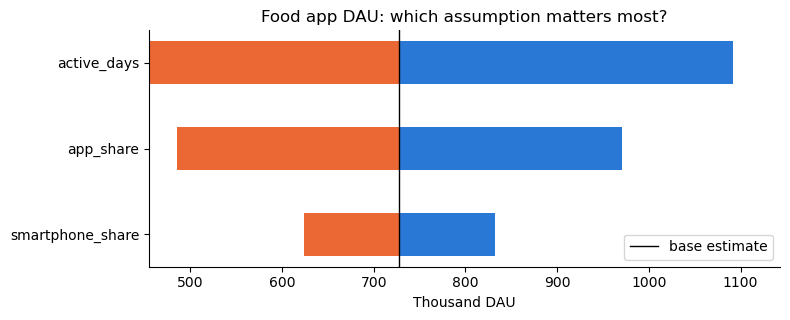

In [8]:
ranges = {
    "smartphone_share": (0.60, 0.80),
    "app_share": (0.20, 0.40),
    "active_days": (5, 12),
}
base_result, table = sensitivity(food_app, base, ranges)
tornado_chart(base_result, table, "Food app DAU: which assumption matters most?", "Thousand DAU", scale=1e3)

Engagement (active days per month) and reach (app share) matter about equally, and both are numbers the company's own data would know exactly. This is a typical situation: a guesstimate shows **which internal metrics** to pull first.

---
## Problem 6 (medium): How many Google searches happen per second?

### 1. Clarify

- All Google web searches worldwide, on all devices.
- Average over a day (we'll also think about the peak).

### 2. Structure

```
searches per second = internet users × share using Google × searches per user per day / 86,400
```

### 3. Assumptions

| Assumption | Value | Reason |
|---|---|---|
| Internet users worldwide | 5.4 billion | About two thirds of the world's 8 billion people |
| Share who use Google search | 75% | Google dominates search in most countries, but not in China (Baidu) or for some users in Russia and Korea |
| Searches per user per day | 3 | Some people search 20 times, many only once or not at all on a given day |
| Seconds per day | 86,400 | 24 × 60 × 60 |

In [9]:
def google_searches_per_second(internet_users, google_share, searches_per_day):
    return internet_users * google_share * searches_per_day / 86_400

base = {"internet_users": 5.4e9, "google_share": 0.75, "searches_per_day": 3}
per_second = google_searches_per_second(**base)
print(f"Searches per day   : {per_second * 86_400 / 1e9:.1f} billion")
print(f"Searches per second: {per_second:,.0f}")

Searches per day   : 12.2 billion
Searches per second: 140,625


By hand: 5.4B × 0.75 × 3 ≈ 12 billion per day. 12,000,000,000 / 86,400 ≈ **140,000 per second**.

### 5. Sanity check

A commonly quoted figure is roughly **8.5 billion searches per day**, which is about 100,000 per second. My estimate is about 1.4× higher. Same order of magnitude. The most likely reason is the 3 searches per user per day: many internet users don't search at all on a given day (they only use apps, messaging and video). With 2 searches per user per day, my estimate drops to about 94,000 per second.

**Average vs peak:** traffic is not flat over the day. Engineers size systems for the **peak**, which is often around 2 times the average, so Google's systems must handle something like 200,000+ searches per second at busy moments.

In [10]:
print(f"With 2 searches per user per day: {google_searches_per_second(5.4e9, 0.75, 2):,.0f} per second")
print(f"Peak at 2x the average          : {2 * per_second:,.0f} per second")

With 2 searches per user per day: 93,750 per second
Peak at 2x the average          : 281,250 per second


---
## Problem 7 (hard): How much storage do photos on a social app need per year?

### 1. Clarify

- A photo-sharing social app with **500 million daily active users**.
- Only photos (no videos, no messages).
- Raw storage needed per year, including the copies a real system keeps.

### 2. Structure

```
photos per day   = DAU × share who post × photos per post
storage per day  = photos per day × size per photo × versions stored × replication
storage per year = storage per day × 365
```

Two things that people often forget, and they multiply the answer:

- **Versions:** each upload is stored at several sizes (original or full size, feed size, thumbnail).
- **Replication:** every file is stored on several machines in different data centres, so a disk failure never loses a photo.

### 3. Assumptions

| Assumption | Value | Reason |
|---|---|---|
| DAU | 500 million | Given |
| Share of DAU who post a photo on a day | 10% | Most users scroll, few post |
| Photos per post | 2 | Some posts are carousels of several photos |
| Size of one stored full-size photo | 400 KB | Phones take 3-5 MB photos, but the app compresses them hard |
| Extra size for other versions | +50% | Feed and thumbnail versions are smaller than the main one |
| Replication factor | 3 | A common choice in distributed storage |

In [11]:
def photo_storage_pb_per_year(dau, share_posting, photos_per_post, photo_kb, versions_factor, replication):
    photos_per_day = dau * share_posting * photos_per_post
    kb_per_day = photos_per_day * photo_kb * versions_factor * replication
    petabytes_per_day = kb_per_day / 1e12      # 1 PB = 10^12 KB
    return petabytes_per_day * 365

base = {"dau": 500e6, "share_posting": 0.10, "photos_per_post": 2, "photo_kb": 400,
        "versions_factor": 1.5, "replication": 3}

photos_per_day = 500e6 * 0.10 * 2
print(f"Photos uploaded per day: {photos_per_day / 1e6:,.0f} million")
print(f"Storage per day        : {photo_storage_pb_per_year(**base) / 365 * 1000:,.0f} TB")
print(f"Storage per year       : {photo_storage_pb_per_year(**base):,.0f} PB")

Photos uploaded per day: 100 million
Storage per day        : 180 TB
Storage per year       : 66 PB


By hand:

- Photos per day = 500M × 0.1 × 2 = **100 million**
- Raw size per day = 100M × 400 KB = 40,000,000,000 KB = 40 TB
- With versions (× 1.5) and replication (× 3): 40 × 4.5 = **180 TB per day**
- Per year: 180 TB × 365 ≈ 66,000 TB ≈ **66 PB per year**

(1 TB = 1,000 GB, 1 PB = 1,000 TB.)

### 5. Sanity check

Two quick checks:

1. **Per user:** 66 PB / 500M users ≈ 130 MB per daily user per year. With all versions and copies, one photo takes about 1.8 MB (400 KB × 4.5), so that's roughly 70 photos per user per year, a bit more than one a week. For an active photo app, plausible.
2. **Hardware:** with 20 TB hard disks, 66 PB is about 3,300 disks a year. A lot, but nothing extreme for a company running data centres.

### 6. Sensitivity

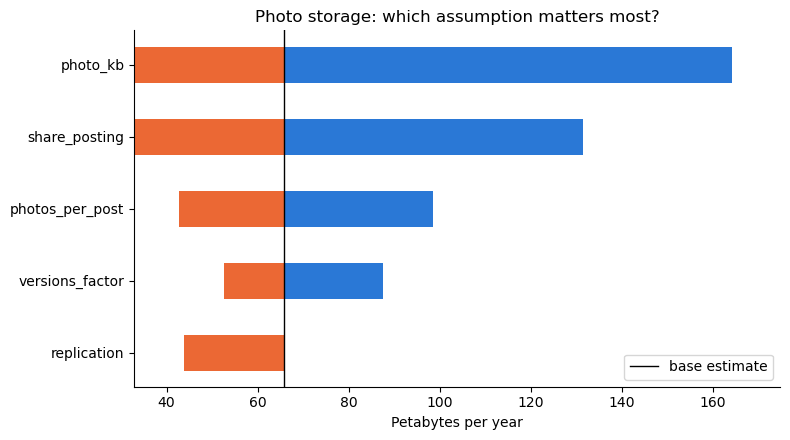

In [12]:
ranges = {
    "share_posting": (0.05, 0.20),
    "photos_per_post": (1.3, 3),
    "photo_kb": (200, 1000),
    "versions_factor": (1.2, 2.0),
    "replication": (2, 3),
}
base_result, table = sensitivity(photo_storage_pb_per_year, base, ranges)
tornado_chart(base_result, table, "Photo storage: which assumption matters most?", "Petabytes per year")

Photo size is the biggest lever, followed by how many users post. That matches what real companies do: better image compression saves far more storage than anything else, which is why formats like WebP and AVIF matter so much to big platforms.

---
## Problem 8 (hard): Monthly revenue of a freemium subscription app

### 1. Clarify

- A photo-editing app with a free version and a paid "Pro" subscription.
- **20 million monthly active users (MAU)**.
- Revenue from subscriptions only, per month, before and after the app store's fee.

### 2. Structure

```
paying users   = MAU × conversion to paid
gross revenue  = paying users × average revenue per paying user per month
net revenue    = gross revenue × (1 − app store fee)
```

The "average revenue per paying user" needs one more step, because people choose between plans:

```
average price per month = share monthly × monthly price + share yearly × (yearly price / 12)
```

### 3. Assumptions

| Assumption | Value | Reason |
|---|---|---|
| MAU | 20 million | Given |
| Conversion to paid | 4% | Freemium apps usually convert a low single-digit percentage of users |
| Monthly plan price | 9.99 € | Typical for a creative app |
| Yearly plan price | 59.99 € | A big discount to push people to the yearly plan |
| Share choosing yearly | 70% | Most subscribers pick the cheaper-per-month option |
| App store fee | 20% | Stores take 30% in the first year and 15% after that for subscriptions. 20% as a blend |

In [13]:
def subscription_revenue(mau, conversion, monthly_price, yearly_price, share_yearly, store_fee):
    paying_users = mau * conversion
    average_price = (1 - share_yearly) * monthly_price + share_yearly * yearly_price / 12
    gross = paying_users * average_price
    return gross * (1 - store_fee)

base = {"mau": 20e6, "conversion": 0.04, "monthly_price": 9.99, "yearly_price": 59.99,
        "share_yearly": 0.70, "store_fee": 0.20}

paying = 20e6 * 0.04
average_price = 0.30 * 9.99 + 0.70 * 59.99 / 12
gross = paying * average_price
net = subscription_revenue(**base)
print(f"Paying users              : {paying:,.0f}")
print(f"Average price per month   : {average_price:.2f} €")
print(f"Gross revenue per month   : {gross / 1e6:.2f} million €")
print(f"Net revenue per month     : {net / 1e6:.2f} million €")
print(f"Net revenue per MAU       : {net / 20e6:.2f} € per month")

Paying users              : 800,000
Average price per month   : 6.50 €
Gross revenue per month   : 5.20 million €
Net revenue per month     : 4.16 million €
Net revenue per MAU       : 0.21 € per month


By hand:

- Paying users = 20M × 0.04 = **800,000**
- Average price = 0.3 × 9.99 + 0.7 × 5.00 = 3.00 + 3.50 = **6.50 € per month**
- Gross = 800,000 × 6.50 ≈ **5.2 million € per month**
- Net after the store's 20% ≈ **4.2 million € per month**, or about 50 million € a year

### 5. Sanity check

Revenue per MAU is about 0.21 € per month. That is low per person, which makes sense when 96% of users pay nothing. Another angle: 800,000 subscribers is like a mid-sized city all paying for the app. For a popular photo app with 20 million users, that feels realistic.

### 6. Sensitivity

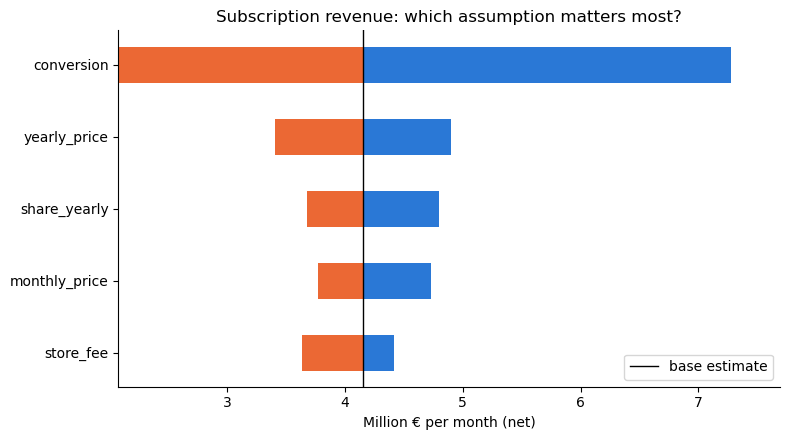

In [14]:
ranges = {
    "conversion": (0.02, 0.07),
    "share_yearly": (0.50, 0.85),
    "monthly_price": (7.99, 12.99),
    "yearly_price": (39.99, 79.99),
    "store_fee": (0.15, 0.30),
}
base_result, table = sensitivity(subscription_revenue, base, ranges)
tornado_chart(base_result, table, "Subscription revenue: which assumption matters most?", "Million € per month (net)", scale=1e6)

Conversion to paid is by far the most important number. Prices matter much less than how many people pay at all. That's why subscription apps spend so much effort on A/B testing their paywall and onboarding screens, which leads straight into the last problem.

---
## Problem 9 (hard): How long must an A/B test run?

This one combines a guesstimate with the sample size formula from the A/B testing notebook.

### 1. Clarify

- An online shop wants to test a new checkout page.
- Metric: **conversion rate** (share of checkout visitors who complete the purchase).
- How many days must the test run to detect the effect they care about?

### 2. Structure

```
users needed per group = sample size formula (baseline rate, minimum detectable effect, α, power)
days needed            = (2 × users needed per group) / checkout visitors per day
```

Then **round up to full weeks**, because shopping behaviour differs between weekdays and weekends.

The formula is the same one used in `02_experimentation/01_ab_testing_part1_design_and_checks.ipynb`, section 5.

### 3. Assumptions

| Assumption | Value | Reason |
|---|---|---|
| Checkout visitors per day | 20,000 | A medium-size online shop |
| Baseline conversion | 3% | Common for e-commerce checkouts |
| Minimum detectable effect (relative) | 5% | 3% → 3.15%. A smaller change wouldn't pay for the work |
| α | 0.05 | Standard |
| Power | 0.80 | Standard |

In [15]:
def sample_size_per_group(p1, p2, alpha=0.05, power=0.80):
    # docs: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html
    z_alpha = stats.norm.ppf(1 - alpha / 2)
    z_beta = stats.norm.ppf(power)
    return (z_alpha + z_beta) ** 2 * (p1 * (1 - p1) + p2 * (1 - p2)) / (p1 - p2) ** 2


def test_duration_days(visitors_per_day, baseline, relative_mde):
    n_per_group = sample_size_per_group(baseline, baseline * (1 + relative_mde))
    return 2 * n_per_group / visitors_per_day

base = {"visitors_per_day": 20_000, "baseline": 0.03, "relative_mde": 0.05}

n_needed = sample_size_per_group(0.03, 0.0315)
days = test_duration_days(**base)
print(f"Users needed per group: {n_needed:,.0f}")
print(f"Days needed           : {days:.1f}")
print(f"Rounded to full weeks : {int(np.ceil(days / 7))} weeks")

Users needed per group: 207,935
Days needed           : 20.8
Rounded to full weeks : 3 weeks


By hand:

- $(1.96 + 0.84)^2 = 7.84$
- $p_1(1-p_1) + p_2(1-p_2) = 0.03 × 0.97 + 0.0315 × 0.9685 = 0.0291 + 0.0305 = 0.0596$
- $(p_1 - p_2)^2 = 0.0015^2 = 0.00000225$
- n per group = 7.84 × 0.0596 / 0.00000225 ≈ **208,000**
- Days = 2 × 208,000 / 20,000 ≈ **21 days → 3 weeks**

### 5. Sanity check

416,000 users in total for a 0.15-point change sounds like a lot, but that's normal: small changes on a small baseline rate need big samples. Compare with the Cookie Cats test, which needed about 24,000 users per group for a 1-point change on a 19% baseline. Our checkout test hunts for an effect almost 7 times smaller in absolute terms, so it needs about 9 times more users.

### 6. Sensitivity

In [16]:
ranges = {
    "visitors_per_day": (10_000, 40_000),
    "baseline": (0.02, 0.05),
    "relative_mde": (0.03, 0.10),
}
base_result, table = sensitivity(test_duration_days, base, ranges)
table.round(3)

,assumption,low value,high value,result if low,result if high,swing
1,baseline,0.02,0.05,31.520,12.212,19.308
0,visitors_per_day,10000.00,40000.00,41.587,10.397,31.190
2,relative_mde,0.03,0.10,57.215,5.321,51.894


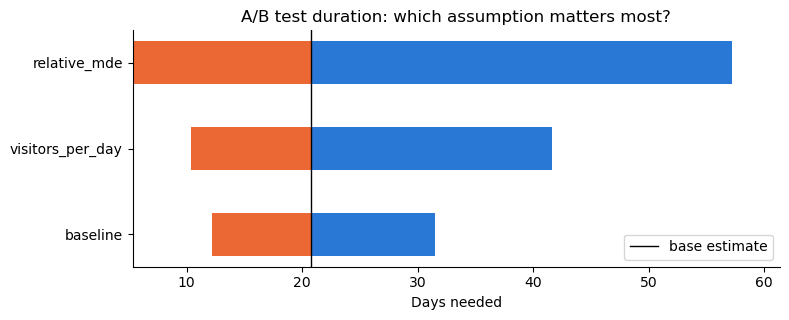

In [17]:
tornado_chart(base_result, table, "A/B test duration: which assumption matters most?", "Days needed")

The minimum detectable effect dominates. Going from a 5% to a 3% relative MDE almost **triples** the duration (because the effect is squared in the formula), while doubling traffic only halves it. In practice, this is the conversation to have with a product team before a test: *"Detecting a 3% lift would take two months. Is a 5% lift a good enough bar?"*

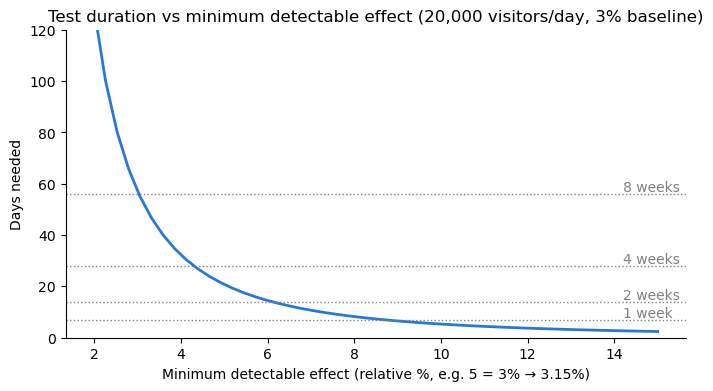

In [18]:
mde_values = np.linspace(0.02, 0.15, 50)
durations = [test_duration_days(20_000, 0.03, mde) for mde in mde_values]

fig, ax = plt.subplots()
ax.plot(mde_values * 100, durations, color=BLUE, linewidth=2)
for weeks in [1, 2, 4, 8]:
    ax.axhline(weeks * 7, color="grey", linestyle=":", linewidth=1)
    ax.text(14.2, weeks * 7 + 1, f"{weeks} week{'s' if weeks > 1 else ''}", color="grey")
ax.set_ylim(0, 120)
ax.set_title("Test duration vs minimum detectable effect (20,000 visitors/day, 3% baseline)")
ax.set_xlabel("Minimum detectable effect (relative %, e.g. 5 = 3% → 3.15%)")
ax.set_ylabel("Days needed")
plt.show()

The curve explodes for small effects. Anything below about a 4% relative lift would take more than a month with this traffic.

---
## Summary

| # | Problem | Estimate | Biggest driver |
|---|---|---|---|
| 4 | Smartphones sold in India per year | about 180 million (after correcting the first try) | Years between purchases |
| 5 | Food app DAU in Bengaluru | about 0.7 million DAU, 0.35 million orders/day | Active days, app share |
| 6 | Google searches per second | about 100,000-140,000 on average, 2× at peak | Searches per user |
| 7 | Photo storage per year | about 66 PB | Photo size after compression |
| 8 | Freemium app revenue | about 4 million € per month net | Conversion to paid |
| 9 | A/B test duration | about 3 weeks | Minimum detectable effect |

Lessons from these problems:

1. **Define the metric first** (DAU vs MAU, gross vs net, average vs peak). Many disagreements are really about definitions.
2. **Cross-check with a second method or a known figure**, and correct openly when they disagree (problem 4).
3. **Look for hidden multipliers** like file versions and replication (problem 7).
4. **The sensitivity check tells you what to research next.** Usually one or two assumptions drive almost everything.

## What's next

This is the end of the guesstimates folder and of the project. Go back to the [README](../README.md) for the full list of notebooks.

## References and further reading

- [Fermi problem, Wikipedia](https://en.wikipedia.org/wiki/Fermi_problem)
- [Sensitivity analysis, Wikipedia](https://en.wikipedia.org/wiki/Sensitivity_analysis)
- Problem 9 reuses the sample size formula from `02_experimentation/01_ab_testing_part1_design_and_checks.ipynb`